# Density Plot with Pandas
* Contributor: Martin Diehl (https://martin-diehl.net)
* DAMASK version: 3.1.0
* Prerequisites (data): DADF5 file with 1. Piola-Kirchhoff stress ('P') and deformation gradient ('F')

In [1]:
%matplotlib inline

In [2]:
import damask
import pandas as pd

In [3]:
# adjust to your situation, file needs to exist
result_file = 'densityplot/20grains16x16x16_tensionX_material.hdf5'
idx = [0,0] # xx-component

In [4]:
result = damask.Result(result_file).view(
    increments=-1,            # only view last increment
    homogenizations=False,    # do not consider homogenization results
)

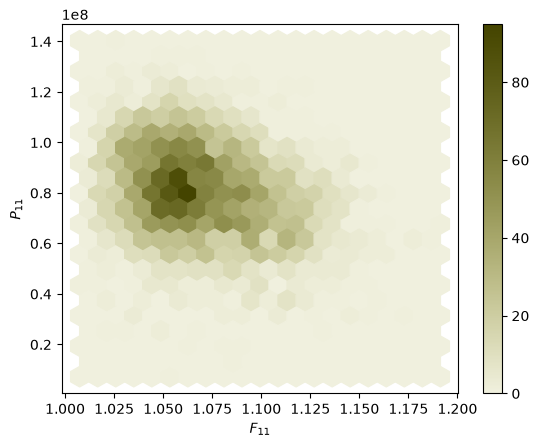

In [5]:
df = pd.DataFrame({'F_11':result.get('F')[:,idx[0],idx[1]],
                   'P_11':result.get('P')[:,idx[0],idx[1]],})
label = f'{idx[0]+1}{idx[1]+1}'
_ = df.plot.hexbin(x=f'F_{label}',y=f'P_{label}',gridsize=20,
                   xlabel=rf'$F_{{{label}}}$',ylabel=rf'$P_{{{label}}}$',
                   cmap=damask.Colormap.from_predefined('strain'))